# DREAM Model — Evaluation Notebook

Reproduces **Table 4** from [Tiyajamorn et al., EMNLP 2021](https://aclanthology.org/2021.emnlp-main.612.pdf).

**Sections**
1. [Configuration](#1.-Configuration) — choose backbone & checkpoint
2. [Load Pipeline](#2.-Load-Pipeline) — instantiate `DREAMPipeline`
3. [Load STS-2017 Data](#3.-Load-STS-2017-Data) — encode all sentence pairs
4. [STS-2017 Evaluation](#4.-STS-2017-Evaluation) — Pearson correlation, backbone vs DREAM
5. [Multilingual t-SNE (all pairs)](#5.-Multilingual-t-SNE-(all-pairs)) — visualise every language pair
6. [Single-pair t-SNE](#6.-Single-pair-t-SNE) — deep-dive into one language pair

## 1. Configuration

In [1]:
from __future__ import annotations

import glob
import sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import ndarray, diag
from scipy.stats import pearsonr
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from torch.cuda import is_available

PROJECT_DIR = Path.cwd().parent
sys.path.insert(0, str(PROJECT_DIR / "src"))

from dream.pipeline import DREAMPipeline

### Select a backbone

Uncomment exactly **one** block below, then run the cell.

In [2]:
# ── sentence-transformers/LaBSE ───────────────────────────────────────────────
# BACKBONE_NAME         = "sentence-transformers/LaBSE"
# BACKBONE_TYPE         = "st"
# CHECKPOINT_PATH       = PROJECT_DIR / "checkpoints" / "labse_vi" / "dream_best.pt"

# ── BAAI/bge-m3 ───────────────────────────────────────────────────────────────
# BACKBONE_NAME         = "BAAI/bge-m3"
# BACKBONE_TYPE         = "bge"
# CHECKPOINT_PATH       = PROJECT_DIR / "checkpoints" / "bge" / "dream_best.pt"

# ── FacebookAI/xlm-roberta-large ─────────────────────────────────────────────
BACKBONE_NAME         = "FacebookAI/xlm-roberta-large"
BACKBONE_TYPE         = "hf"
CHECKPOINT_PATH       = PROJECT_DIR / "checkpoints" / "xlmr_vi" / "dream_best.pt"

# ── google-bert/bert-base-multilingual-cased ─────────────────────────────────
# BACKBONE_NAME           = "google-bert/bert-base-multilingual-cased"
# BACKBONE_TYPE           = "hf"
# CHECKPOINT_PATH         = PROJECT_DIR / "checkpoints" / "mbert" / "dream_best.pt"

# ─────────────────────────────────────────────────────────────────────────────
BACKBONE_DISPLAY_NAME   = BACKBONE_NAME.split("/")[-1]
print(f"Backbone : {BACKBONE_NAME}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Backbone : FacebookAI/xlm-roberta-large
Checkpoint: d:\_PythonProjects\DREAM-vi\DREAM-vi\checkpoints\xlmr_vi\dream_best.pt


### Data path & device

In [3]:
STS17_PATH  = PROJECT_DIR / "data" / "STS17"
ENCODE_BATCH = 64
DEVICE       = "cuda" if is_available() else "cpu"

print(f"STS-2017 path : {STS17_PATH}")
print(f"Device        : {DEVICE}")

STS-2017 path : d:\_PythonProjects\DREAM-vi\DREAM-vi\data\STS17
Device        : cuda


## 2. Load Pipeline

In [4]:
dream_pipeline = DREAMPipeline.from_pretrained(
    checkpoint_path=CHECKPOINT_PATH,
    backbone=BACKBONE_NAME,
    backbone_type=BACKBONE_TYPE,
    device=DEVICE,
)
print(dream_pipeline)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DREAMPipeline(backbone='FacebookAI/xlm-roberta-large', dream=DREAMModel(
  embedding_dim=1024, num_languages=8
  (meaning_encoder): Linear(in_features=1024, out_features=1024, bias=True)
  (language_encoder): Linear(in_features=1024, out_features=1024, bias=True)
  (language_identifier): Linear(in_features=1024, out_features=8, bias=True)
), device=cuda)


## 3. Load STS-2017 Data

Each STS-2017 file is encoded through both the raw backbone and the full DREAM
pipeline. Results are stored in `STS17Embedding` dataclasses for later reuse —
so encoding runs only once.

In [5]:
@dataclass
class STS17Embedding:
    """All embeddings and ground-truth similarities for one language pair."""
    lang_pair: str                   # e.g. "en-de"

    sent1: list[str]
    sent2: list[str]
    similarity: list[float]          # human-annotated similarity scores

    # Raw backbone embeddings
    emb_sent1_backbone: ndarray      # (N, D)
    emb_sent2_backbone: ndarray      # (N, D)

    # DREAM meaning embeddings
    emb_sent1_dream: ndarray         # (N, D)
    emb_sent2_dream: ndarray         # (N, D)

    # DREAM language embeddings
    lang_sent1_dream: ndarray        # (N, D)
    lang_sent2_dream: ndarray        # (N, D)

In [6]:
def load_sts17(
    path: Path,
    pipeline: DREAMPipeline,
    batch_size: int = 64,
) -> list[STS17Embedding]:
    """
    Load all STS-2017 language-pair files and encode every sentence.

    Returns a list of STS17Embedding — one entry per language pair found
    under `path/STS.*.txt`.
    """
    txt_files = sorted(glob.glob(str(path / "STS.*.txt")))
    if not txt_files:
        raise FileNotFoundError(f"No STS-2017 files found in: {path}")

    records = []
    for txt in txt_files:
        lang_pair = Path(txt).stem.split(".")[-1]   # e.g. "en-de"
        df = pd.read_csv(
            txt, sep="\t", header=None,
            names=["sent1", "sent2", "sim"],
            on_bad_lines="skip",
        )

        # Ensure English is always sent1
        if lang_pair.startswith("en"):
            sent1, sent2 = df["sent1"].tolist(), df["sent2"].tolist()
        else:
            sent1, sent2 = df["sent2"].tolist(), df["sent1"].tolist()

        print(f"  Encoding {lang_pair} ({len(sent1)} pairs) …")

        emb1_bb = pipeline.encode(sent1, batch_size=batch_size, only_backbone=True)
        emb2_bb = pipeline.encode(sent2, batch_size=batch_size, only_backbone=True)

        emb1_m, lang1, _ = pipeline.dream_forward(sent1, batch_size=batch_size)
        emb2_m, lang2, _ = pipeline.dream_forward(sent2, batch_size=batch_size)

        records.append(STS17Embedding(
            lang_pair=lang_pair,
            sent1=sent1,
            sent2=sent2,
            similarity=df["sim"].astype(float).tolist(),
            emb_sent1_backbone=emb1_bb,
            emb_sent2_backbone=emb2_bb,
            emb_sent1_dream=emb1_m,
            emb_sent2_dream=emb2_m,
            lang_sent1_dream=lang1,
            lang_sent2_dream=lang2,
        ))

    return records

In [7]:
sts17 = load_sts17(STS17_PATH, dream_pipeline, batch_size=ENCODE_BATCH)
print(f"\nLoaded {len(sts17)} language pair(s).")

  Encoding en-ar (250 pairs) …
  Encoding en-de (250 pairs) …
  Encoding en-tr (250 pairs) …
  Encoding en-vi (250 pairs) …
  Encoding es-en (250 pairs) …
  Encoding fr-en (250 pairs) …
  Encoding it-en (250 pairs) …
  Encoding nl-en (250 pairs) …

Loaded 8 language pair(s).


## 4. STS-2017 Evaluation

Pearson correlation between cosine similarity of sentence embeddings and
human-annotated similarity scores.

A higher Pearson *r* means the embedding space better reflects human judgement.
The DREAM meaning embedding should consistently outperform the raw backbone
on cross-lingual pairs.

In [8]:
def pairwise_cosine(a: ndarray, b: ndarray) -> ndarray:
    """Element-wise cosine similarity for paired rows: shape (N,)."""
    return diag(cosine_similarity(a, b))

In [9]:
results = {}
for data in sts17:
    backbone_sim = pairwise_cosine(data.emb_sent1_backbone, data.emb_sent2_backbone)
    dream_sim    = pairwise_cosine(data.emb_sent1_dream,    data.emb_sent2_dream)

    results[data.lang_pair] = {
        "backbone": round(pearsonr(backbone_sim, data.similarity)[0], 4),
        "dream":    round(pearsonr(dream_sim,    data.similarity)[0], 4),
    }

results_df = pd.DataFrame(results)
results_df.index = ["Backbone", "DREAM (meaning)"]
results_df["avg"] = results_df.mean(axis=1).round(4)
results_df

,en-ar,en-de,en-tr,en-vi,es-en,fr-en,it-en,nl-en,avg
Backbone,0.1908,0.1173,0.1306,0.0237,0.0319,0.1623,0.1405,0.1185,0.1144
DREAM (meaning),0.4168,0.4757,0.4935,0.2844,0.4497,0.5026,0.5381,0.5431,0.4630


## 5. Multilingual t-SNE (all pairs)

t-SNE projects high-dimensional embeddings to 2D for visual inspection.

- **Backbone** — baseline; languages may or may not be clustered separately.
- **Backbone + Meaning layer** — DREAM's goal: languages should *overlap*,
  showing language-agnostic alignment.
- **Backbone + Language layer** — languages should *separate*, confirming that
  language-specific information has been isolated.

In [10]:
TSNE_N    = 250    # sentences sampled per language for t-SNE
TSNE_SEED = 42


def fit_tsne(
    emb1: np.ndarray,
    emb2: np.ndarray,
    n: int = TSNE_N,
    seed: int = TSNE_SEED,
) -> tuple[np.ndarray, int]:
    """
    Sample up to `n` points from each embedding set, stack them, and fit t-SNE.

    Returns:
        coords : (2*n, 2) projected coordinates
        n1     : number of points from emb1 (needed to split the plot)
    """
    rng  = np.random.RandomState(seed)
    idx1 = rng.choice(len(emb1), min(n, len(emb1)), replace=False)
    idx2 = rng.choice(len(emb2), min(n, len(emb2)), replace=False)
    stacked = np.vstack([emb1[idx1], emb2[idx2]])
    coords  = TSNE(
        n_components=2, perplexity=30,
        random_state=seed, max_iter=1000,
    ).fit_transform(stacked)
    return coords, len(idx1)


def plot_tsne_ax(
    ax,
    coords: np.ndarray,
    n1: int,
    label1: str,
    label2: str,
    title: str,
) -> None:
    """Render a single t-SNE scatter panel onto `ax`."""
    ax.scatter(
        coords[:n1, 0], coords[:n1, 1],
        c="steelblue", label=label1, alpha=0.6, s=12, edgecolors="none",
    )
    ax.scatter(
        coords[n1:, 0], coords[n1:, 1],
        c="tomato", label=label2, alpha=0.6, s=12, edgecolors="none",
    )
    ax.legend(loc="lower right", fontsize=8, markerscale=2)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

  Running t-SNE for en-ar …
  Running t-SNE for en-de …
  Running t-SNE for en-tr …
  Running t-SNE for en-vi …
  Running t-SNE for es-en …
  Running t-SNE for fr-en …
  Running t-SNE for it-en …
  Running t-SNE for nl-en …

Saved → d:\_PythonProjects\DREAM-vi\DREAM-vi\assets\xlm-roberta-large_tsne.png


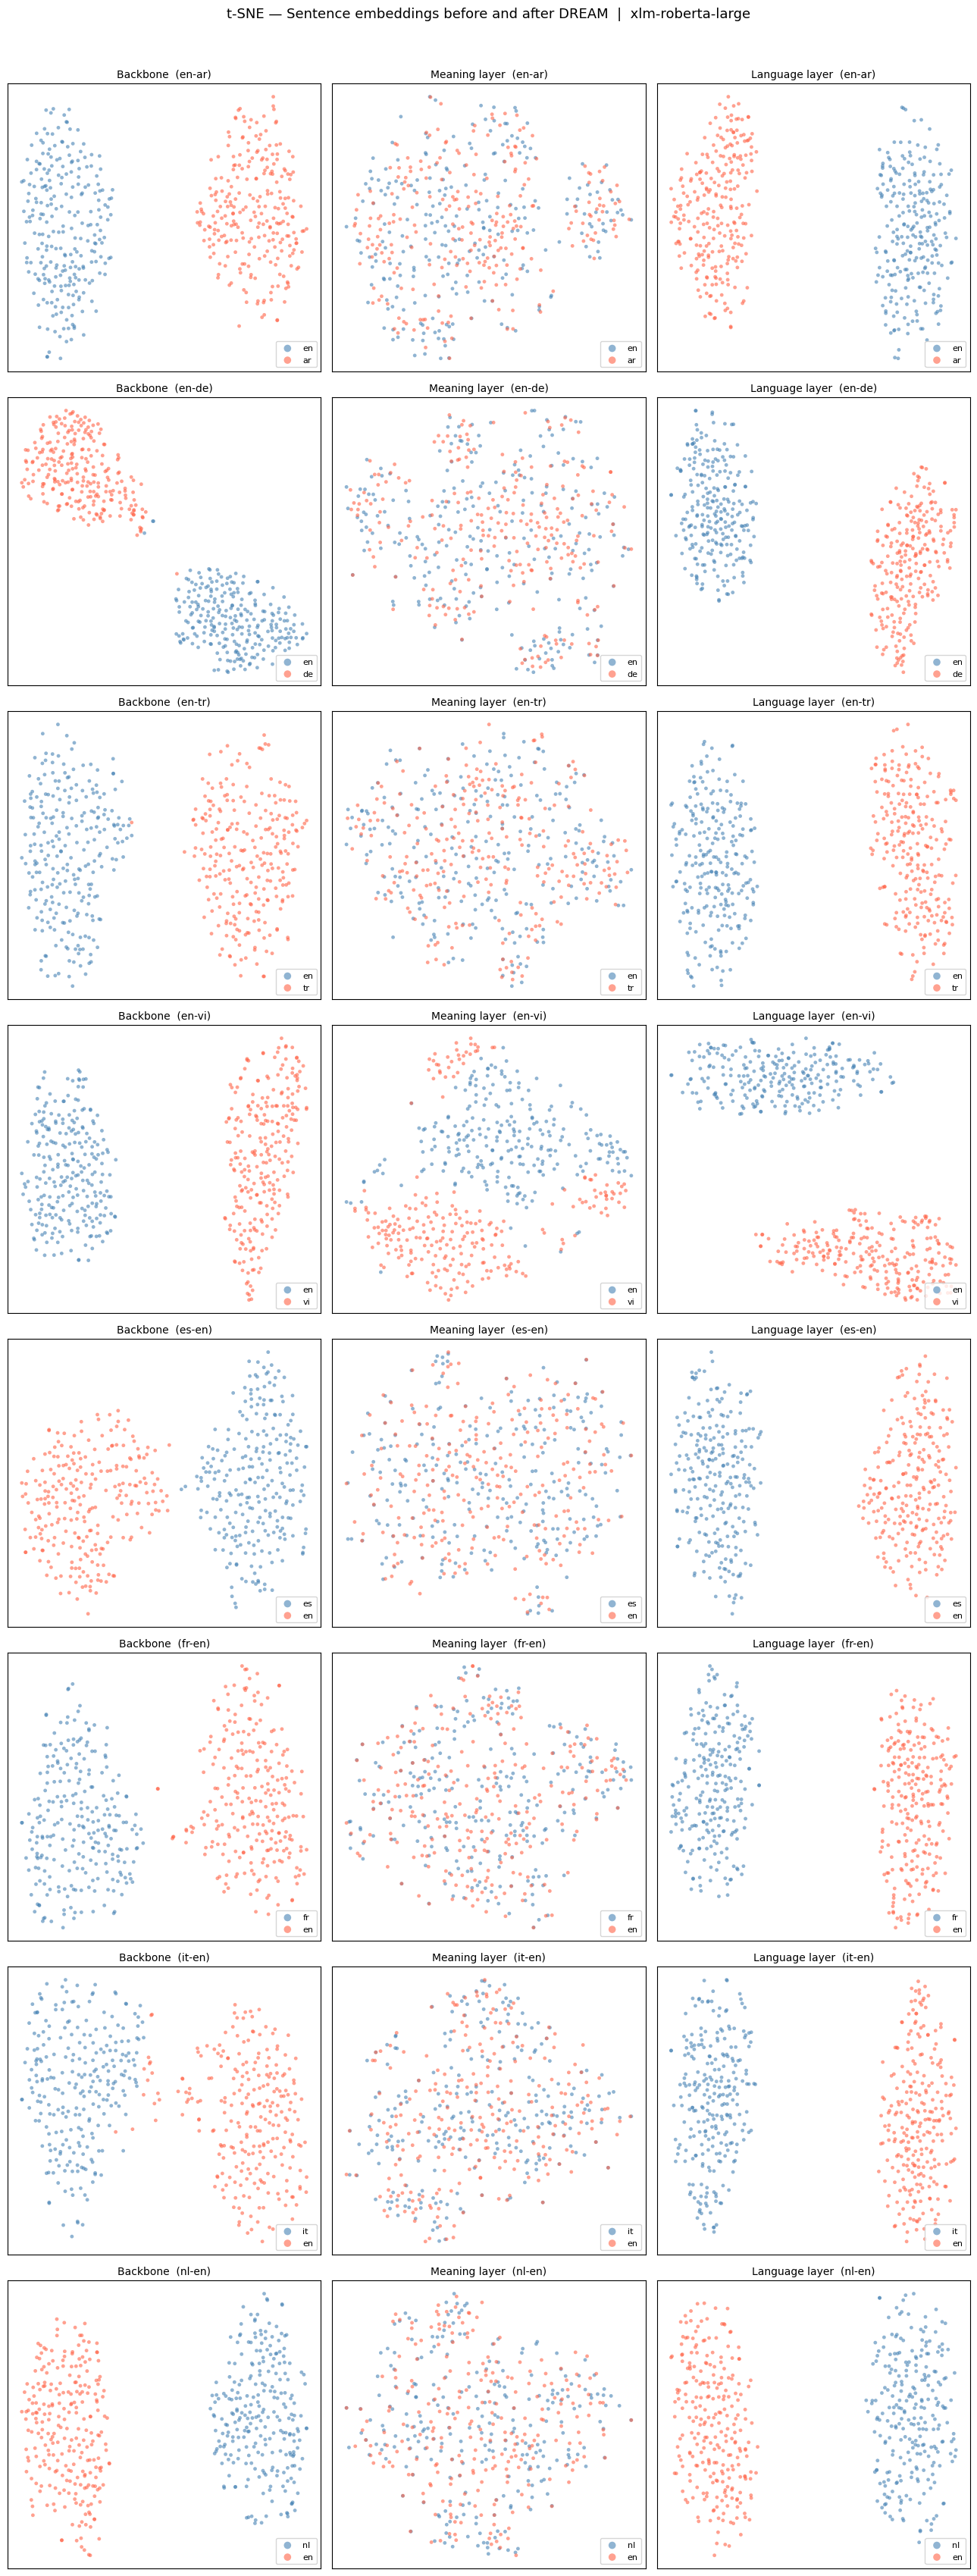

In [11]:
ASSETS_DIR = PROJECT_DIR / "assets"
ASSETS_DIR.mkdir(exist_ok=True)

n_pairs = len(sts17)
fig, axes = plt.subplots(n_pairs, 3, figsize=(13, 4.2 * n_pairs))

if n_pairs == 1:
    axes = axes[np.newaxis, :]

# Column header labels
col_labels = [
    BACKBONE_DISPLAY_NAME,
    f"{BACKBONE_DISPLAY_NAME} — Meaning layer",
    f"{BACKBONE_DISPLAY_NAME} — Language layer",
]
for col, label in enumerate(col_labels):
    axes[0, col].set_title(label, fontsize=10, fontweight="bold", pad=10)

for row, data in enumerate(sts17):
    lang1, lang2 = data.lang_pair.split("-")
    print(f"  Running t-SNE for {data.lang_pair} …")

    coords, n1 = fit_tsne(data.emb_sent1_backbone, data.emb_sent2_backbone)
    plot_tsne_ax(axes[row, 0], coords, n1, lang1, lang2,
                 title=f"Backbone  ({data.lang_pair})")

    coords, n1 = fit_tsne(data.emb_sent1_dream, data.emb_sent2_dream)
    plot_tsne_ax(axes[row, 1], coords, n1, lang1, lang2,
                 title=f"Meaning layer  ({data.lang_pair})")

    coords, n1 = fit_tsne(data.lang_sent1_dream, data.lang_sent2_dream)
    plot_tsne_ax(axes[row, 2], coords, n1, lang1, lang2,
                 title=f"Language layer  ({data.lang_pair})")

fig.suptitle(
    f"t-SNE — Sentence embeddings before and after DREAM  |  {BACKBONE_DISPLAY_NAME}",
    fontsize=13, y=1.01,
)
plt.tight_layout()

save_path = ASSETS_DIR / f"{BACKBONE_DISPLAY_NAME}_tsne.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"\nSaved → {save_path}")
plt.show()

## 6. Single-pair t-SNE

A focused, publication-quality view for **one language pair**.
Set `VIZ_LANG_PAIR` to any pair present in your STS-2017 data
(e.g. `"en-de"`, `"en-fr"`, `"en-es"`).

In [12]:
# ── User config ───────────────────────────────────────────────────────────────
VIZ_LANG_PAIR = "en-vi"   # change to any pair in your STS-2017 data
VIZ_N         = 300       # sentences per language
# ─────────────────────────────────────────────────────────────────────────────

# Retrieve the matching STS17Embedding
data = next((d for d in sts17 if d.lang_pair == VIZ_LANG_PAIR), None)
if data is None:
    available = [d.lang_pair for d in sts17]
    raise ValueError(f"{VIZ_LANG_PAIR!r} not found. Available: {available}")

lang1, lang2 = data.lang_pair.split("-")
print(f"Visualising: {data.lang_pair}  ({len(data.sent1)} sentence pairs)")

Visualising: en-vi  (250 sentence pairs)


Running t-SNE (3 × fit) …
Saved → d:\_PythonProjects\DREAM-vi\DREAM-vi\assets\xlm-roberta-large_en-vi_tsne.png


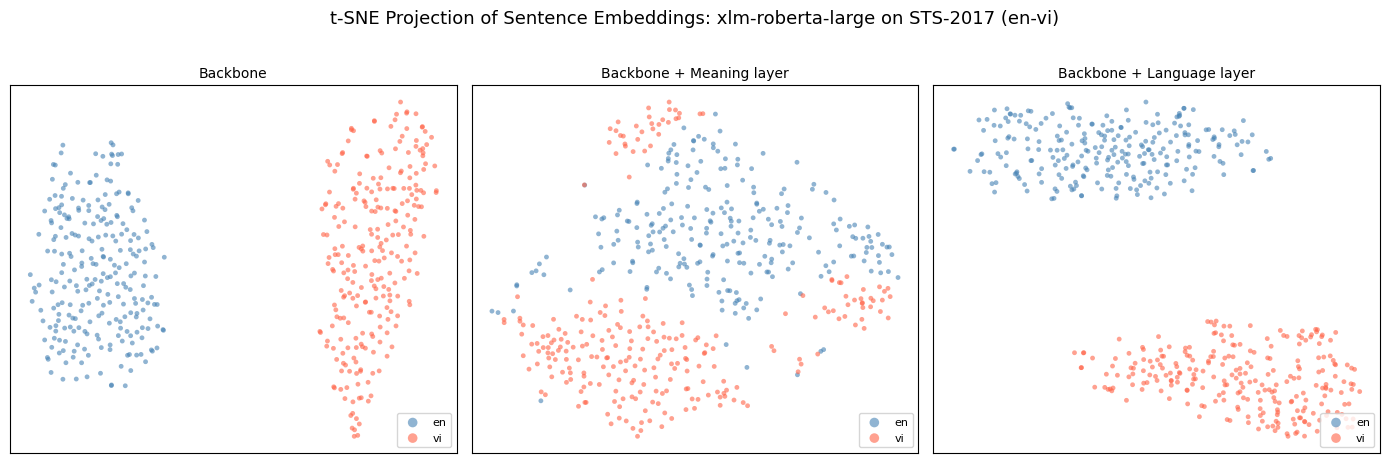

In [13]:
print("Running t-SNE (3 × fit) …")

panel_configs = [
    ("Backbone",        data.emb_sent1_backbone, data.emb_sent2_backbone),
    ("Backbone + Meaning layer",   data.emb_sent1_dream,    data.emb_sent2_dream),
    ("Backbone + Language layer",  data.lang_sent1_dream,   data.lang_sent2_dream),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (panel_title, emb1, emb2) in zip(axes, panel_configs):
    coords, n1 = fit_tsne(emb1, emb2, n=VIZ_N, seed=TSNE_SEED)
    plot_tsne_ax(ax, coords, n1, lang1, lang2, title=panel_title)

fig.suptitle(
    f"t-SNE Projection of Sentence Embeddings: {BACKBONE_DISPLAY_NAME} on STS-2017 ({VIZ_LANG_PAIR})",
    fontsize=13, y=1.02,
)
plt.tight_layout()

save_path = ASSETS_DIR / f"{BACKBONE_DISPLAY_NAME}_{VIZ_LANG_PAIR}_tsne.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved → {save_path}")
plt.show()